# Machine Learning e Data Science com Python de A à Z - IA Expert Academy

## Dados desbalanceados

### Preparação dos dados

Dados desbalanceados

Quantidade muito grande de uma classe e poucos registros de outra classe


conda Udemy

In [1]:
import pandas as pd
import numpy as np
print(pd.__version__)
print(np.__version__) # antes estava 1.26.4, atualizado para 2.3.4

2.3.3
2.3.4


In [2]:
#!pip install numpy
#!pip install --force-reinstall "numpy>=2.0"
#https://www.kaggle.com/code/rafjaa/resampling-strategies-for-imbalanced-datasets

In [3]:
base_census = pd.read_csv('census.csv')
base_census.tail()

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


previsão da renda da pessoa (income), se ganha mais do que 50mil ou menos por ano

In [4]:
np.unique(base_census['income'], return_counts = True)

(array([' <=50K', ' >50K'], dtype=object), array([24720,  7841]))

dados desbalanceados, <=50K maior que o >50K 

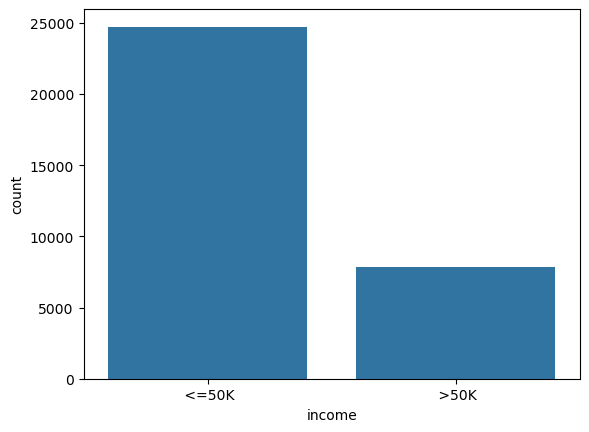

In [5]:
import seaborn as sns
sns.countplot(x = base_census['income']);

In [6]:
print(f' colunas para a base de previsão : {list(base_census.columns[0:14])}')

 colunas para a base de previsão : ['age', 'workclass', 'final-weight', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loos', 'hour-per-week', 'native-country']


In [7]:

# criar o atributo previsores do census
X_census = base_census.iloc[:, 0:14].values
X_census # convertendo para o numpy array

array([[39, ' State-gov', 77516, ..., 0, 40, ' United-States'],
       [50, ' Self-emp-not-inc', 83311, ..., 0, 13, ' United-States'],
       [38, ' Private', 215646, ..., 0, 40, ' United-States'],
       ...,
       [58, ' Private', 151910, ..., 0, 40, ' United-States'],
       [22, ' Private', 201490, ..., 0, 20, ' United-States'],
       [52, ' Self-emp-inc', 287927, ..., 0, 40, ' United-States']],
      shape=(32561, 14), dtype=object)

In [8]:
# previsão: income, objetivo para a verificar à frente.

In [9]:
y_census = base_census.iloc[:, 14].values
y_census[:200]

array([' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' >50K', ' >50K', ' >50K', ' >50K', ' >50K', ' <=50K',
       ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K',
       ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K',
       ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' >50K', ' >50K', ' <=50K', ' >50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K',
       ' <=50K', ' <=50K', ' <=50K', ' >50K', ' >50K', ' <=50K', ' <=50K',
       ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' >50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' >50K',
       ' <=50K', ' <=50K

### vamos converter 

### atributos categóricos (string ou palavras) será alterado para códigos em números (ou atributos numéricos), para se trabalhar, usando o LabelEncoder

In [10]:
from sklearn.preprocessing import LabelEncoder
label_encoder_workclass = LabelEncoder()
label_encoder_education = LabelEncoder()
label_encoder_marital = LabelEncoder()
label_encoder_occupation = LabelEncoder()
label_encoder_relationship = LabelEncoder()
label_encoder_race = LabelEncoder()
label_encoder_sex = LabelEncoder()
label_encoder_country = LabelEncoder()

In [11]:
X_census[:,1] = label_encoder_workclass.fit_transform(X_census[:,1])
X_census[:,3] = label_encoder_education.fit_transform(X_census[:,3])
X_census[:,5] = label_encoder_marital.fit_transform(X_census[:,5])
X_census[:,6] = label_encoder_occupation.fit_transform(X_census[:,6])
X_census[:,7] = label_encoder_relationship.fit_transform(X_census[:,7])
X_census[:,8] = label_encoder_race.fit_transform(X_census[:,8])
X_census[:,9] = label_encoder_sex.fit_transform(X_census[:,9])
X_census[:,13] = label_encoder_country.fit_transform(X_census[:,13])

In [12]:
X_census

array([[39, 7, 77516, ..., 0, 40, 39],
       [50, 6, 83311, ..., 0, 13, 39],
       [38, 4, 215646, ..., 0, 40, 39],
       ...,
       [58, 4, 151910, ..., 0, 40, 39],
       [22, 4, 201490, ..., 0, 20, 39],
       [52, 5, 287927, ..., 0, 40, 39]], shape=(32561, 14), dtype=object)

# 28.3) subamostragem tomek links

### Subamostragem com Tomek Links

In [13]:
from imblearn.under_sampling import TomekLinks

In [14]:
print(f'quantidade dados puro {len(base_census)}')

quantidade dados puro 32561


In [15]:
# tl tomeklinks
tl = TomekLinks(sampling_strategy='majority') # estratégia para trabalhar (balanceamento maior ou igual a 50K)
X_under, y_under = tl.fit_resample(X_census, y_census) #Atualizado 20/05/2022


https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.TomekLinks.html

##### class imblearn.under_sampling.TomekLinks(*, sampling_strategy='auto', n_jobs=None)

'majority': resample only the majority class; maior quantidade de registro da classe (pegar a maior)

'not minority': resample all classes but the minority class;

'not majority': resample all classes but the majority class;

'all': resample all classes; fazer o balanceamento para todas as  (deleta o excesso de ambas as partes)

'auto': equivalent to 'not minority'.

In [16]:
X_under.shape, y_under.shape # deletou mais de 2mil.

((30160, 14), (30160,))

In [17]:
# contagem de elementos

In [18]:
np.unique(y_census, return_counts=True) # original 

(array([' <=50K', ' >50K'], dtype=object), array([24720,  7841]))

In [19]:
np.unique(y_under, return_counts=True) # processo tomek links majority

(array([' <=50K', ' >50K'], dtype=object), array([22319,  7841]))

In [20]:
# balancear com todas as classes

tl = TomekLinks(sampling_strategy='all') # estratégia para trabalhar (balanceamento maior ou igual a 50K)
X_under, y_under = tl.fit_resample(X_census, y_census) #Atualizado 20/05/2022
print(X_under.shape, y_under.shape) # deletou mais de 2mil.
np.unique(y_under, return_counts=True) 
# processo tomek links all (percebeu que além de balancear os dados '<=50K', foi também para o '>50K')
# apagando as colunas

(27759, 14) (27759,)


(array([' <=50K', ' >50K'], dtype=object), array([22319,  5440]))

coleta dos dados próximos

apaga os dados próximos

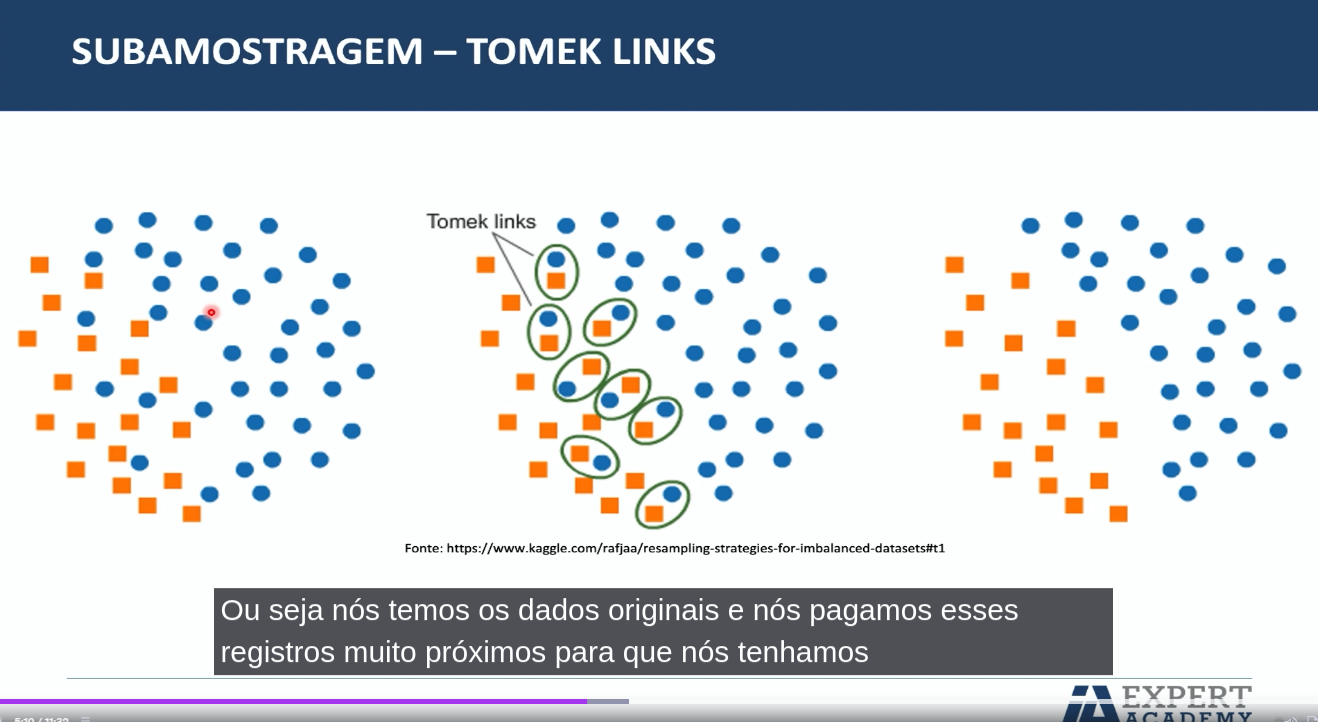

o Majoraty apaga apenas os registros da class azul,

já o all apaga os registros laranja e azul. classes majoritárias e minoritárias

o algoritmo calcula as distâncias, com registros de alta similaridade.

## fazer as transformações desses atributos categóricos

In [21]:
# balancear com todas as classes

tl = TomekLinks(sampling_strategy='majority') # estratégia para trabalhar (balanceamento maior ou igual a 50K)
X_under, y_under = tl.fit_resample(X_census, y_census) #Atualizado 20/05/2022
print(X_under.shape, y_under.shape) # deletou mais de 2mil.
np.unique(y_under, return_counts=True) 
# processo tomek links majority (percebeu os dados '<=50K')


(30160, 14) (30160,)


(array([' <=50K', ' >50K'], dtype=object), array([22319,  7841]))

In [22]:
colunas = list(base_census.columns)
print('id, coluna')
for i, col in enumerate(colunas):
    print(i,col)


id, coluna
0 age
1 workclass
2 final-weight
3 education
4 education-num
5 marital-status
6 occupation
7 relationship
8 race
9 sex
10 capital-gain
11 capital-loos
12 hour-per-week
13 native-country
14 income


In [23]:
X_census

array([[39, 7, 77516, ..., 0, 40, 39],
       [50, 6, 83311, ..., 0, 13, 39],
       [38, 4, 215646, ..., 0, 40, 39],
       ...,
       [58, 4, 151910, ..., 0, 40, 39],
       [22, 4, 201490, ..., 0, 20, 39],
       [52, 5, 287927, ..., 0, 40, 39]], shape=(32561, 14), dtype=object)

Transforma a coluna: ColumnTransformer

transformers: É uma lista de tuplas que define as transformações.

"OneHot": etapa de transformação.

OneHotEncoder(): O transformador a ser aplicado. Ele converte variáveis categóricas (como 'país', 'estado civil') em um formato binário (0s e 1s).

[1, 3, 5, 6, 7, 8, 9, 13]: Lista de índices das colunas (baseado em zero) na minha tabela: X_census que devem receber o One-Hot Encoding.

remainder='passthrough': Define o que fazer com as colunas que não estão listadas nos transformers. O passthrough significa que todas as outras colunas numéricas (ou quaisquer colunas não listadas) serão mantidas inalteradas no conjunto de dados transformado.


### onehotencorder.fit_transform(X_census):

fit: O ColumnTransformer (e o OneHotEncoder dentro dele) aprende as categorias únicas presentes nas colunas de índices [1, 3, 5, 6, 7, 8, 9, 13] do X_census.

transform: O encoder cria novas colunas binárias para cada categoria aprendida. Onde havia uma única coluna categórica (por exemplo, "Estado Civil"), agora haverá várias colunas binárias (por exemplo, "Casado", "Solteiro", "Divorciado"), com 1 ou 0 indicando a presença daquela categoria. As colunas numéricas originais são apenas passadas.

.toarray(): A saída do ColumnTransformer é um formato de matriz esparsa (sparse matrix) que economiza memória. O .toarray() converte essa saída para uma matriz NumPy densa tradicional, que é o formato exigido pela maioria dos algoritmos de Machine Learning.

In [24]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
onehotencorder = ColumnTransformer(transformers=[("OneHot", OneHotEncoder(), [1,3,5,6,7,8,9,13])],remainder='passthrough')
X_census_2 = onehotencorder.fit_transform(X_census).toarray()
X_census_2

array([[0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 2.1740e+03, 0.0000e+00,
        4.0000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        1.3000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        4.0000e+01],
       ...,
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        4.0000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.5024e+04, 0.0000e+00,
        4.0000e+01]], shape=(32561, 108))

In [25]:
print(X_census.shape)


(32561, 14)


In [26]:
# treinamento e teste, para verificar se é válido ou não

In [27]:
from sklearn.model_selection import train_test_split
#15% para testar  e resto para o treinamento
X_census_treinamento_under, X_census_teste_under, y_census_treinamento_under, y_census_teste_under = train_test_split(X_census_2, y_census, test_size=0.15, random_state=0)
X_census_treinamento_under.shape, X_census_teste_under.shape

((27676, 108), (4885, 108))

In [28]:
# 84.70% com os dados originais
# dados obtidos pelo meio do tunning
# criado o algoritmo
from sklearn.ensemble import RandomForestClassifier
random_forest_census = RandomForestClassifier(criterion = 'entropy', min_samples_leaf =  1, min_samples_split = 5, n_estimators = 100)
random_forest_census.fit(X_census_treinamento_under, y_census_treinamento_under)

,n_estimators,100
,criterion,'entropy'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


ambos com 85,08% de acurácia

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 0, 'verbose': 0, 'warm_start': False}




{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 0, 'verbose': 0, 'warm_start': False}


In [29]:
print(random_forest_census.get_params())


{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


In [30]:
# acurácia do modelo (arquivo census.csv

# a acurácia, lembrando que no 2-Naive_Bayes_Bayesiano.ipynb, método bayesiano a acurácia era de apenas 47,68% no census
# a acurácia, lembrando que no 3-3_Arvore_decision_Census_parte4.ipynb, método da árvore de decisão simples a acurácia era de 81,04% no census
# a acurácia, lembrando que no 3-5_Arvore_decision_Random_Forest_Census.ipynb método das múltiplas árvores
# => A acurácia do modelo é de 85.08% para 100 árvores (n_estimators).


# a acurácia, lembrando que no 4-4_InducaodeRegras_BaseCEnsus.ipynb, método das regras => Acurácia do modelo 75.92 %

# Acurácia da instância KNN 82.23 % com 5 vizinhos próximos
# Acurácia da instância KNN 82.91 % ideal 10 vizinhos próximos, 5-2AprendizagemKNN_BaseCensus.ipynb

#Acurácia da Regressão Logística 84.97 %, 6-3RegressaoLogistica_BaseCensus.ipynb

#Acurácia da SVM - Support Vector Machine 85.08 %, para Kernel: linear e C: 1.0 , 7-2_SVM_Supporte_Vector_Machine_Base_census.ipynb


#A acurácia deep learning é de 81.56%, hidden_layer_sizes = (55,55))

#-------------------------
#naive bayes - tabela de probabilidade

#árvore de decisão - estrutura de dados

#regras - gera regras e classificar

#instância Knn- vizinhos mais próximos, e calcula as distâncias (armazena os dados)

#regressão logistica - melhor curva possível para classificar os registros 

#algoritmo SVM - encontrar uma linha com a margem máxima

#redes neurais - deep learning

In [31]:
# passando somente os dados de teste para a previsão
from sklearn.metrics import accuracy_score, classification_report
previsoes = random_forest_census.predict(X_census_teste_under)
accuracy_score(y_census_teste_under, previsoes)

0.8532241555783009

In [32]:
acuracia = accuracy_score(y_census_teste_under, previsoes)
print()
print('A acurácia do modelo é de {:.2f}% para 100 árvores (n_estimators).'.format(acuracia*100))


A acurácia do modelo é de 85.32% para 100 árvores (n_estimators).


In [33]:
# previsa fazer o teste com a validação cruzada, 30 vezes

In [34]:
# balancear com todas as classes

tl = TomekLinks(sampling_strategy='all') # estratégia para trabalhar (balanceamento maior ou igual a 50K)
X_under, y_under = tl.fit_resample(X_census, y_census) #Atualizado 20/05/2022
print(X_under.shape, y_under.shape) # deletou mais de 2mil.
np.unique(y_under, return_counts=True) 
# processo tomek links all (mexeu nos dados '<=50K' e  '>50K')


(27759, 14) (27759,)


(array([' <=50K', ' >50K'], dtype=object), array([22319,  5440]))

In [35]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
onehotencorder = ColumnTransformer(transformers=[("OneHot", OneHotEncoder(), [1,3,5,6,7,8,9,13])],remainder='passthrough')
X_under_ohe = onehotencorder.fit_transform(X_under).toarray()
X_under_ohe

array([[    0.,     0.,     0., ...,  2174.,     0.,    40.],
       [    0.,     0.,     0., ...,     0.,     0.,    40.],
       [    0.,     0.,     0., ...,     0.,     0.,    40.],
       ...,
       [    0.,     0.,     0., ...,     0.,     0.,    40.],
       [    0.,     0.,     0., ...,     0.,     0.,    20.],
       [    0.,     0.,     0., ..., 15024.,     0.,    40.]],
      shape=(27759, 108))

In [36]:
np.unique(y_under, return_counts=True)

(array([' <=50K', ' >50K'], dtype=object), array([22319,  5440]))

In [38]:
X_under.shape, y_under.shape

((27759, 14), (27759,))

In [37]:
X_under_ohe.shape, X_under.shape

((27759, 108), (27759, 14))

In [39]:
from sklearn.model_selection import train_test_split
X_census_treinamento_under, X_census_teste_under, y_census_treinamento_under, y_census_teste_under = train_test_split(X_under, y_under, test_size=0.15, random_state=0)
X_census_treinamento_under.shape, X_census_teste_under.shape

((23595, 14), (4164, 14))

In [40]:
# 84.70% com os dados originais
from sklearn.ensemble import RandomForestClassifier
random_forest_census = RandomForestClassifier(criterion = 'entropy', min_samples_leaf =  1, min_samples_split = 5, n_estimators = 100)
random_forest_census.fit(X_census_treinamento_under, y_census_treinamento_under)
print(random_forest_census.get_params())


{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


In [41]:
from sklearn.metrics import accuracy_score, classification_report
previsoes = random_forest_census.predict(X_census_teste_under)
accuracy_score(y_census_teste_under, previsoes)
acuracia = accuracy_score(y_census_teste_under, previsoes)
print()
print('A acurácia do modelo é de {:.2f}% para 100 árvores (n_estimators).'.format(acuracia*100)) # melhorou a acurácia


A acurácia do modelo é de 89.05% para 100 árvores (n_estimators).


In [42]:
# apagando os dois registros, com as duas superfícies melhores.